# Feature exploration: optflow_features.npz & pose_tensor.npz

Explore the contents of:
- **optflow_features.npz** — optical flow–derived features (speed, direction, etc.)
- **pose_tensor.npz** — pose tracks (position, velocity, acceleration, hand landmarks)

Sample: `ipn_train_1CM1_4_R_#229_B0A_900_1122` (223 frames).

## Feature glossary

### optflow_features.npz (optical flow, per frame)

| Feature | Shape | Description |
|--------|--------|-------------|
| **timestamps_ms** | `(T,)` | Time of each frame in milliseconds (typically ~33.33 ms ≈ 30 fps). |
| **avg_speed** | `(T,)` | **Average speed** of flow in the region of interest (ROI). Magnitude of motion; higher = more movement. |
| **max_speed** | `(T,)` | **Maximum** flow speed in the ROI (pixel/frame or normalized). Highlights peak motion. |
| **dominant_angle_deg** | `(T,)` | **Dominant direction** of flow in degrees (e.g. 0° = right, 90° = down). Main motion direction. |
| **direction_concentration** | `(T,)` | How **concentrated** the flow direction is (e.g. 0–1). High = motion mostly one direction; low = mixed directions. |
| **n_pixels** | `(T,)` | Number of pixels **above the motion threshold** in the ROI. Indicates how much of the region is moving. |
| **threshold** | `(T,)` | Motion **threshold** used for that frame (e.g. Otsu or fixed). Pixels above this count as moving. |
| **valid** | `(T,)` | Boolean mask: `True` if flow for that frame was successfully computed and meets quality checks. |
| **meta_json** | — | Processing parameters: `roi_size_hw`, `resample_dt_ms`, `threshold_method`, `subtract_bg`, etc. |

### pose_tensor.npz (hand pose, per frame)

| Feature | Shape | Description |
|--------|--------|-------------|
| **timestamps_ms** | `(T,)` | Same time base as optflow; frames are aligned. |
| **track_pos_xyz** | `(T, 3)` | **3D position** of the track point (e.g. wrist) in the pose coordinate system (see meta: `track_point`, `spatial_origin`). |
| **track_vel_xyz** | `(T, 3)` | **3D velocity** of the track point (derived from position over time). Units depend on coordinate system. |
| **track_acc_xyz** | `(T, 3)` | **3D acceleration** of the track point. Useful for detecting motion onset/offset. |
| **landmarks_xyz** | `(T, 21, 3)` | **21 hand keypoints** (x, y, z) per frame. MediaPipe hand layout: wrist, thumb (4), index (4), middle (4), ring (4), pinky (4). |
| **valid** | `(T,)` | Boolean: `True` if hand was detected and pose is valid for that frame. |
| **meta_json** | — | Config: `backend` (e.g. mediapipe_hands), `track_point` (e.g. wrist), `coord_system`, `resample_dt_ms`, `origin`, etc. |

**Typical use:** Optflow captures **appearance-based motion** (e.g. texture/edges moving in the ROI). Pose captures **skeleton-based motion** (wrist and finger positions). Both are resampled to a common `resample_dt_ms` so they align frame-by-frame for fusion or joint models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

ROOT = Path(".") if Path("data").exists() else Path("..")
SAMPLE_DIR = ROOT / "data" / "processed" / "ipn_hand" / "train" / "ipn_train_1CM1_4_R_#229_B0A_900_1122"
OPTFLOW_PATH = SAMPLE_DIR / "optflow_features.npz"
POSE_PATH = SAMPLE_DIR / "pose_tensor.npz"

## 1. Load and inspect structure

In [18]:
opt = np.load(OPTFLOW_PATH, allow_pickle=True)
pose = np.load(POSE_PATH, allow_pickle=True)

print("=== optflow_features.npz ===")
for k in opt.files:
    arr = opt[k]
    print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}")

print("\n=== pose_tensor.npz ===")
for k in pose.files:
    arr = pose[k]
    print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}")

=== optflow_features.npz ===
  timestamps_ms: shape=(223,), dtype=float32
  avg_speed: shape=(223,), dtype=float32
  max_speed: shape=(223,), dtype=float32
  dominant_angle_deg: shape=(223,), dtype=float32
  direction_concentration: shape=(223,), dtype=float32
  n_pixels: shape=(223,), dtype=int32
  threshold: shape=(223,), dtype=float32
  valid: shape=(223,), dtype=bool
  meta_json: shape=(1,), dtype=object

=== pose_tensor.npz ===
  timestamps_ms: shape=(223,), dtype=float32
  track_pos_xyz: shape=(223, 3), dtype=float32
  track_vel_xyz: shape=(223, 3), dtype=float32
  track_acc_xyz: shape=(223, 3), dtype=float32
  landmarks_xyz: shape=(223, 21, 3), dtype=float32
  valid: shape=(223,), dtype=bool
  meta_json: shape=(1,), dtype=object


In [19]:
# Print optflow and pose features (names + sample values, first 5 frames)
np.set_printoptions(precision=4, suppress=True)

print("--- Optflow features ---")
for k in opt.files:
    if k == "meta_json":
        continue
    arr = opt[k]
    print(f"\n{k} ({arr.shape}, {arr.dtype}):")
    if arr.ndim == 1:
        print(arr[:5] if len(arr) >= 5 else arr)
    else:
        print(arr[:5] if len(arr) >= 5 else arr)

print("\n--- Pose features ---")
for k in pose.files:
    if k == "meta_json":
        continue
    arr = pose[k]
    print(f"\n{k} ({arr.shape}, {arr.dtype}):")
    if arr.ndim == 1:
        print(arr[:5] if len(arr) >= 5 else arr)
    elif arr.ndim == 2:
        print(arr[:5] if len(arr) >= 5 else arr)
    else:
        print("(first frame)", arr[0])
        if len(arr) > 1:
            print("(last frame)", arr[-1])

--- Optflow features ---

timestamps_ms ((223,), float32):
[  0.     33.333  66.666  99.999 133.332]

avg_speed ((223,), float32):
[    nan     nan  8.3587  3.0195 12.2394]

max_speed ((223,), float32):
[    nan     nan 13.1663  5.6699 24.6298]

dominant_angle_deg ((223,), float32):
[    nan     nan 51.6277 49.6369 75.5317]

direction_concentration ((223,), float32):
[   nan    nan 0.9945 0.8396 0.9874]

n_pixels ((223,), int32):
[    0     0 12962 16942 20157]

threshold ((223,), float32):
[   nan    nan 4.6548 1.6009 6.4714]

valid ((223,), bool):
[False False  True  True  True]

--- Pose features ---

timestamps_ms ((223,), float32):
[  0.     33.333  66.666  99.999 133.332]

track_pos_xyz ((223, 3), float32):
[[ 0.      0.      0.    ]
 [ 0.0093 -0.0017 -0.    ]
 [ 0.0208  0.0027 -0.    ]
 [ 0.0255  0.0036 -0.    ]
 [ 0.0463 -0.0033 -0.    ]]

track_vel_xyz ((223, 3), float32):
[[ 0.2785 -0.0518 -0.    ]
 [ 0.3122  0.04   -0.    ]
 [ 0.2427  0.08   -0.    ]
 [ 0.3822 -0.0899 -0.   

In [3]:
# Meta (if present)
if "meta_json" in opt.files:
    print("Optflow meta:", opt["meta_json"].item())
if "meta_json" in pose.files:
    print("Pose meta:", pose["meta_json"].item())

Optflow meta: {"fixed_threshold": 2.0, "resample_dt_ms": 33.333, "roi_size_hw": [224, 224], "subtract_bg": true, "threshold_method": "otsu"}
Pose meta: {"backend": "mediapipe_hands", "coord_system": "mediapipe_normalized", "origin": [0.4371066689491272, 0.8470319509506226, 4.405821130148979e-07], "resample_dt_ms": 33.333, "rotation_normalize": true, "spatial_origin": "first_wrist", "track_point": "wrist"}


## 2. Optical flow features (time series)

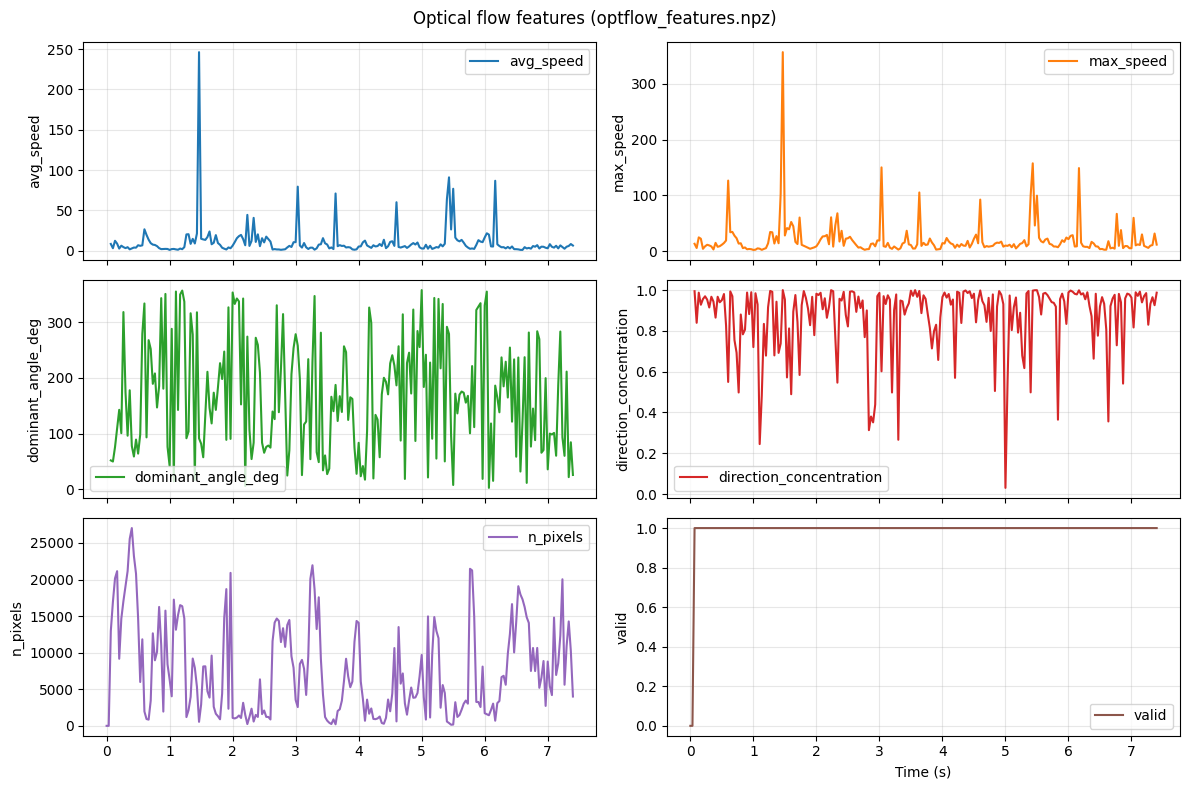

In [4]:
t_ms = opt["timestamps_ms"]
t_s = t_ms / 1000.0

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

axes[0].plot(t_s, opt["avg_speed"], label="avg_speed")
axes[0].set_ylabel("avg_speed")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_s, opt["max_speed"], color="C1", label="max_speed")
axes[1].set_ylabel("max_speed")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_s, opt["dominant_angle_deg"], color="C2", label="dominant_angle_deg")
axes[2].set_ylabel("dominant_angle_deg")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_s, opt["direction_concentration"], color="C3", label="direction_concentration")
axes[3].set_ylabel("direction_concentration")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[4].plot(t_s, opt["n_pixels"], color="C4", label="n_pixels")
axes[4].set_ylabel("n_pixels")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

axes[5].plot(t_s, opt["valid"].astype(float), color="C5", label="valid")
axes[5].set_ylabel("valid")
axes[5].set_xlabel("Time (s)")
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.suptitle("Optical flow features (optflow_features.npz)", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Summary stats (valid frames only)
v = opt["valid"]
print("Optflow — valid frames:", v.sum(), "/", len(v))
for name in ["avg_speed", "max_speed", "dominant_angle_deg", "direction_concentration", "n_pixels"]:
    arr = opt[name]
    if v.any():
        print(f"  {name}: mean={np.nanmean(arr[v]):.4f}, std={np.nanstd(arr[v]):.4f}, min={np.nanmin(arr[v]):.4f}, max={np.nanmax(arr[v]):.4f}")
    else:
        print(f"  {name}: (no valid frames)")

Optflow — valid frames: 221 / 223
  avg_speed: mean=10.5429, std=20.9062, min=0.9272, max=246.2714
  max_speed: mean=20.6396, std=33.3169, min=2.2147, max=356.4728
  dominant_angle_deg: mean=167.9915, std=101.6507, min=2.1927, max=358.0737
  direction_concentration: mean=0.8718, std=0.1717, min=0.0304, max=0.9999
  n_pixels: mean=7641.9231, std=6379.5793, min=150.0000, max=27028.0000


## 3. Pose tensor (track + landmarks)

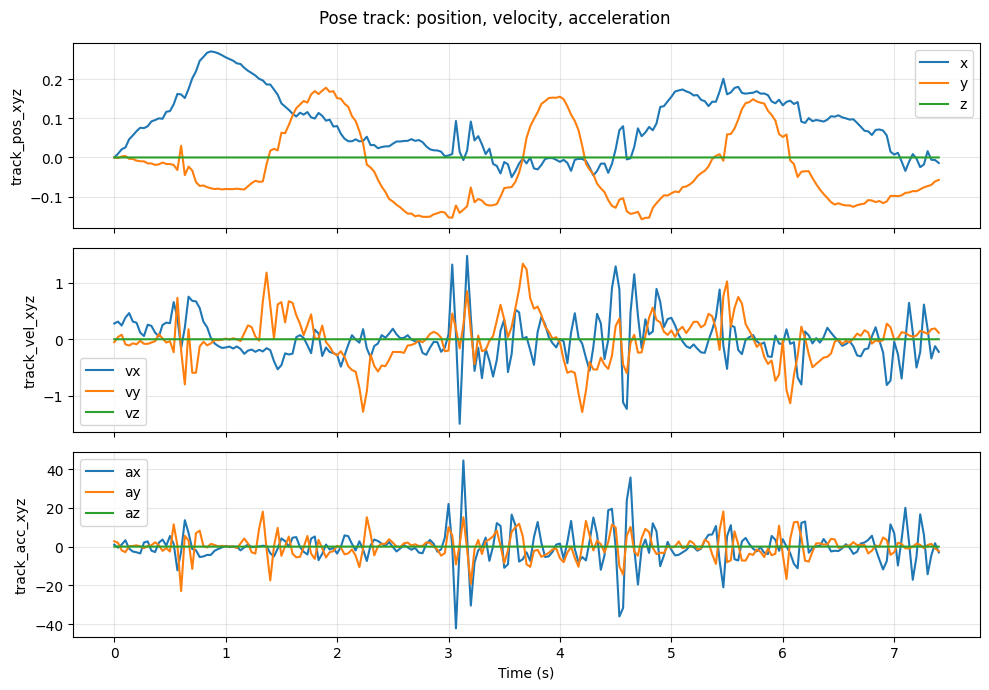

In [6]:
t_pose = pose["timestamps_ms"] / 1000.0
pos = pose["track_pos_xyz"]   # (T, 3)
vel = pose["track_vel_xyz"]   # (T, 3)
acc = pose["track_acc_xyz"]   # (T, 3)
landmarks = pose["landmarks_xyz"]  # (T, 21, 3)
valid_pose = pose["valid"]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t_pose, pos[:, 0], label="x")
axes[0].plot(t_pose, pos[:, 1], label="y")
axes[0].plot(t_pose, pos[:, 2], label="z")
axes[0].set_ylabel("track_pos_xyz")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_pose, vel[:, 0], label="vx")
axes[1].plot(t_pose, vel[:, 1], label="vy")
axes[1].plot(t_pose, vel[:, 2], label="vz")
axes[1].set_ylabel("track_vel_xyz")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_pose, acc[:, 0], label="ax")
axes[2].plot(t_pose, acc[:, 1], label="ay")
axes[2].plot(t_pose, acc[:, 2], label="az")
axes[2].set_ylabel("track_acc_xyz")
axes[2].set_xlabel("Time (s)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Pose track: position, velocity, acceleration", fontsize=12)
plt.tight_layout()
plt.show()

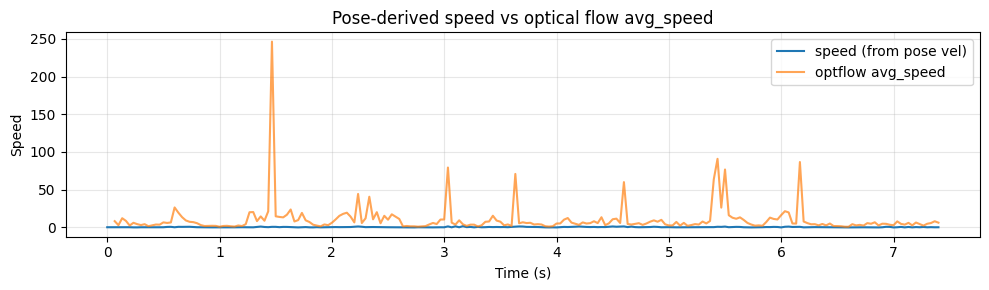

In [7]:
# Speed from pose velocity
speed_pose = np.linalg.norm(vel, axis=1)
plt.figure(figsize=(10, 3))
plt.plot(t_pose, speed_pose, label="speed (from pose vel)")
plt.plot(opt["timestamps_ms"] / 1000.0, opt["avg_speed"], alpha=0.7, label="optflow avg_speed")
plt.ylabel("Speed")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Pose-derived speed vs optical flow avg_speed")
plt.tight_layout()
plt.show()

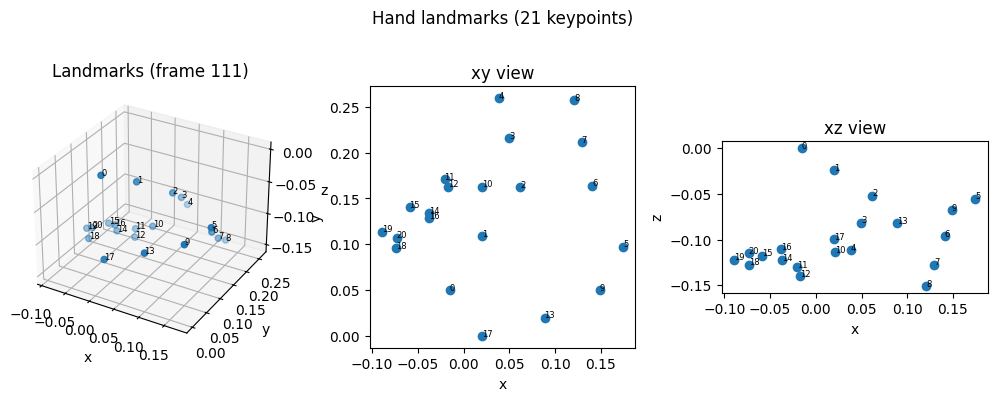

In [8]:
# Landmarks: 21 keypoints x (x,y,z), one frame (e.g. mid clip)
frame_idx = len(landmarks) // 2
lm = landmarks[frame_idx]  # (21, 3)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(131, projection="3d")
ax.scatter(lm[:, 0], lm[:, 1], lm[:, 2], s=20)
for i in range(len(lm)):
    ax.text(lm[i, 0], lm[i, 1], lm[i, 2], str(i), fontsize=6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Landmarks (frame {frame_idx})")

ax2 = fig.add_subplot(132)
ax2.scatter(lm[:, 0], lm[:, 1])
for i in range(len(lm)):
    ax2.annotate(str(i), (lm[i, 0], lm[i, 1]), fontsize=6)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("xy view")
ax2.set_aspect("equal")

ax3 = fig.add_subplot(133)
ax3.scatter(lm[:, 0], lm[:, 2])
for i in range(len(lm)):
    ax3.annotate(str(i), (lm[i, 0], lm[i, 2]), fontsize=6)
ax3.set_xlabel("x")
ax3.set_ylabel("z")
ax3.set_title("xz view")
ax3.set_aspect("equal")

plt.suptitle("Hand landmarks (21 keypoints)")
plt.tight_layout()
plt.show()

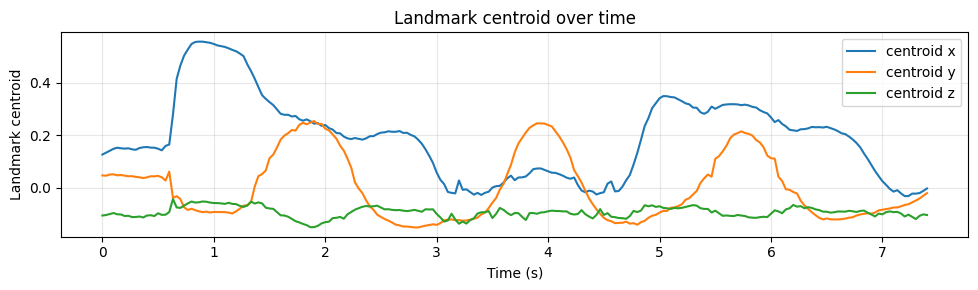

In [9]:
# Landmark motion over time: centroid or selected keypoint
centroid = landmarks.mean(axis=1)  # (T, 3)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(t_pose, centroid[:, 0], label="centroid x")
ax.plot(t_pose, centroid[:, 1], label="centroid y")
ax.plot(t_pose, centroid[:, 2], label="centroid z")
ax.set_ylabel("Landmark centroid")
ax.set_xlabel("Time (s)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.title("Landmark centroid over time")
plt.tight_layout()
plt.show()

## 4. Valid masks

In [10]:
print("Optflow valid:", opt["valid"].sum(), "/", len(opt["valid"]))
print("Pose valid:", pose["valid"].sum(), "/", len(pose["valid"]))
both = opt["valid"] & pose["valid"]
print("Both valid:", both.sum(), "/", len(both))

Optflow valid: 221 / 223
Pose valid: 223 / 223
Both valid: 221 / 223


In [11]:
opt.close()
pose.close()